## PROJECT OVERVIEW
**Project Title:-**  Flipkart Customer Service Satisfaction



##### **Contribution**    - Individual

# **Problem Statement**


The goal of this project is to build a machine learning classification model that predicts customer satisfaction levels based on customer support interaction data. By analyzing factors such as response time, issue category, agent interaction, and communication channel, Flipkart can identify key drivers of satisfaction and improve overall customer service quality.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Customer_support_data (1).csv')

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(85907, 20)

### Dataset Information

In [ ]:
#checking for duplicate rows
float(df.duplicated().sum())

0.0

#### Missing Values/Null Values

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [ ]:
# Visualizing the missing values
#percentage of missing value per column
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent = missing_percent.sort_values(ascending = False)

#display as a dataframe
missing_df = missing_percent.reset_index()
missing_df.columns = ['column','%Missing']
print(missing_df)

                     column   %Missing
0   connected_handling_time  99.718300
1             Customer_City  80.119199
2          Product_category  79.983005
3                Item_price  79.971364
4           order_date_time  79.962052
5          Customer Remarks  66.542889
6                  Order_id  21.222950
7                 Unique id   0.000000
8              Sub-category   0.000000
9                  category   0.000000
10             channel_name   0.000000
11        Issue_reported at   0.000000
12          issue_responded   0.000000
13     Survey_response_Date   0.000000
14               Agent_name   0.000000
15               Supervisor   0.000000
16                  Manager   0.000000
17            Tenure Bucket   0.000000
18              Agent Shift   0.000000
19               CSAT Score   0.000000


In [ ]:
# Fill missing values in categorical columns safely
df['Customer Remarks'] = df['Customer Remarks'].fillna('No Remarks')
df['Product_category'] = df['Product_category'].fillna('Unknown')

# Drop columns that are not needed
df = df.drop(['Unique id', 'Order_id', 'order_date_time',
              'connected_handling_time', 'Customer_City'], axis=1)


## ***2. Understanding Your Variables***

In [ ]:
df.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'Issue_reported at', 'issue_responded', 'Survey_response_Date',
       'Product_category', 'Item_price', 'Agent_name', 'Supervisor', 'Manager',
       'Tenure Bucket', 'Agent Shift', 'CSAT Score'],
      dtype='object')

In [ ]:
len(df.columns)

15

In [ ]:
df.describe()

,Item_price,CSAT Score
count,17206.000000,85907.000000
mean,5660.774846,4.242157
std,12825.728411,1.378903
min,0.000000,1.000000
25%,392.000000,4.000000
50%,979.000000,5.000000
75%,2699.750000,5.000000
max,164999.000000,5.000000


### Check Unique Values for each variable.

In [ ]:
df.nunique()

,0
channel_name,3
category,12
Sub-category,57
Customer Remarks,18232
Issue_reported at,30923
issue_responded,30262
Survey_response_Date,31
Product_category,10
Item_price,2789
Agent_name,1371


In [ ]:
# Separate numerical and categorical features

num_features = [feature for feature in df.columns if df[feature].dtype != "O"]
cat_features = [feature for feature in df.columns if df[feature].dtype == "O"]

print('There are {} numerical features: {}'.format(len(num_features), num_features))
print('There are {} categorical features: {}'.format(len(cat_features), cat_features))


# Unique values in categorical features
for i in cat_features:
    print(f"{df[i].nunique()} unique categories in '{i}' are:")
    print(df[i].unique())
    print()


There are 2 numerical features: ['Item_price', 'CSAT Score']
There are 13 categorical features: ['channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Product_category', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']
3 unique categories in 'channel_name' are:
['Outcall' 'Inbound' 'Email']

12 unique categories in 'category' are:
['Product Queries' 'Order Related' 'Returns' 'Cancellation'
 'Shopzilla Related' 'Payments related' 'Refund Related' 'Feedback'
 'Offers & Cashback' 'Onboarding related' 'Others' 'App/website']

57 unique categories in 'Sub-category' are:
['Life Insurance' 'Product Specific Information' 'Installation/demo'
 'Reverse Pickup Enquiry' 'Not Needed' 'Fraudulent User'
 'Exchange / Replacement' 'Missing' 'General Enquiry' 'Return request'
 'Delayed' 'Service Centres Related' 'Payment related Queries'
 'Order status enquiry' 'Return cancellation' 'Unable to track'
 'Selle

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Convert columns to datetime
df['Issue_reported at'] = pd.to_datetime(
    df['Issue_reported at'],
    format="%d/%m/%Y %H:%M"
)

df['issue_responded'] = pd.to_datetime(
    df['issue_responded'],
    format="%d/%m/%Y %H:%M"
)

# Calculate response time in hours
df['Respond_time'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds() / 3600

# Optional: round to 2 decimal places
df['Respond_time'] = df['Respond_time'].round(2)


In [ ]:
float(df['Respond_time'].max())

95.97

In [ ]:
float(df['Respond_time'].min())

-23.95

In [ ]:
negative_resolve_df = df[df['Respond_time'] < 0][
    ['issue_responded', 'Issue_reported at', 'Respond_time']
]
negative_resolve_df.head()


,issue_responded,Issue_reported at,Respond_time
74172,2023-08-28,2023-08-28 16:07:00,-16.12
74173,2023-08-28,2023-08-28 16:56:00,-16.93
74174,2023-08-28,2023-08-28 20:14:00,-20.23
74175,2023-08-28,2023-08-28 14:37:00,-14.62
74176,2023-08-28,2023-08-28 23:26:00,-23.43


In [ ]:
#  Calculate mean of only valid (positive) response times
mean_respond_time = df[df['Respond_time'] > 0]['Respond_time'].mean()

# Replace negative values with this mean
df.loc[df['Respond_time'] < 0, 'Respond_time'] = mean_respond_time

# Optional: round again if needed
df['Respond_time'] = df['Respond_time'].round(2)

# Check to confirm no more negative values
print(df['Respond_time'].min())

0.0


The code calculates the mean of valid response times, replaces all negative values with this mean, rounds the results, and confirms data cleaning by checking that no negative response times remain

In [ ]:
df.drop(['issue_responded','Issue_reported at'], axis = 1, inplace = True)

In [ ]:
df.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'Survey_response_Date', 'Product_category', 'Item_price', 'Agent_name',
       'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'Respond_time'],
      dtype='object')

In [ ]:
print(len(df.columns))

14


## Sentiment analysis

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

# Normalize text
df['Customer Remarks'] = (
    df['Customer Remarks']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Non-informative remarks
no_remark_values = [
    "", " ", "none", "no", "no remarks", "no remark",
    "no comments", "n/a", "na", "-", ".", "nil", "missing"
]

df['Customer Remarks'] = df['Customer Remarks'].replace(no_remark_values, "missing")

def classify_sentiment(text):
    if text == "missing":
        return "missing"

    score = sia.polarity_scores(text)['compound']
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

df['Sentiment'] = df['Customer Remarks'].apply(classify_sentiment)


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
pd.set_option('display.max_rows', None)
df['Sentiment'].head(20)

,Sentiment
0,missing
1,missing
2,missing
3,missing
4,missing
5,missing
6,missing
7,positive
8,positive
9,missing


In [ ]:
#percentage of negative remarks out of total record
neg_pct = (df['Sentiment'].value_counts(normalize=True)['negative']) * 100
print(f"Percentage of negative remarks: {neg_pct:.2f}%")

Percentage of negative remarks: 5.17%


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

<Axes: xlabel='CSAT Score', ylabel='Count'>

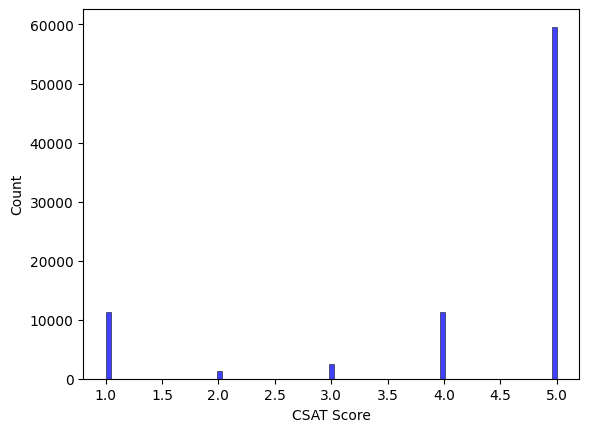

In [ ]:
#Graph 1: CSAT Score
import seaborn as sns
sns.histplot(data = df,x = 'CSAT Score',color = 'blue')

##### 1. Why did you pick the specific chart?

We use this graph to understand how customer satisfaction is distributed across all customers.

##### 2. What is/are the insight(s) found from the chart?

It is cleary visible that 5 dominates hevaily, indicating very high customer satisfaction.
Very few low scores (1–2), suggesting limited dissatisfaction

#### Chart - 2

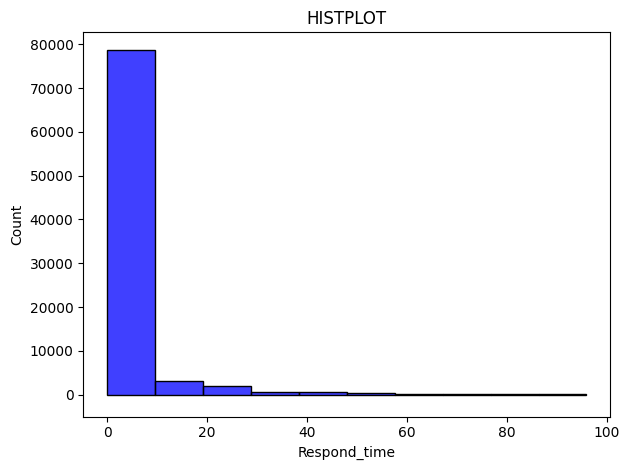

In [ ]:
#Graph 2: Respond Time
sns.histplot(data =df,x='Respond_time',kde = False,bins =10,color = 'blue')
plt.title('HISTPLOT')
plt.ylim(-5000)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

 We use this histogram to understand the distribution of response time in customer support

##### 2. What is/are the insight(s) found from the chart?

Response times show a right-skewed distribution, with most customer queries resolved quickly. A small number of cases experience unusually long response times, creating outliers and extending the distribution’s right tail.

In [ ]:
count_over_48 = df[df['Respond_time']>48].shape[0]
print(f"Number of rows with respond time > 48 hours:{count_over_48}")

Number of rows with respond time > 48 hours:999


A total of 999 records show response times exceeding 48 hours, indicating delayed issue resolution for a notable subset of customers. These prolonged responses may negatively impact customer satisfaction and highlight areas needing process or staffing improvements.

#### Chart - 3

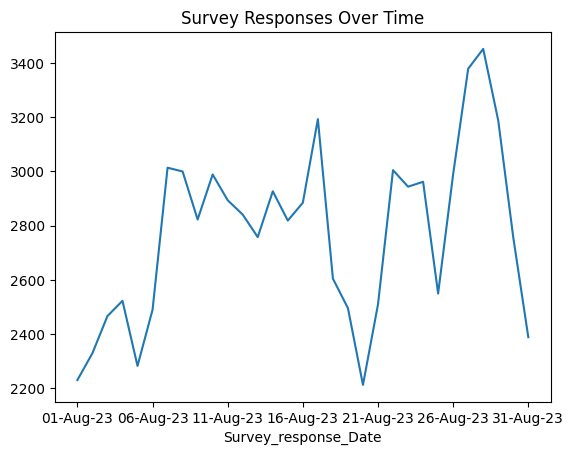

In [ ]:
#Graph 3: Survey_response_date
df['Survey_response_Date'].value_counts().sort_index().plot()
plt.title("Survey Responses Over Time")
plt.show()

##### 1. Why did you pick the specific chart?

This graph is used to analyze customer response patterns over time and identify periods of high or low survey participation.

##### 2. What is/are the insight(s) found from the chart?

The graph shows fluctuating but generally increasing survey responses over time, with peak customer engagement toward the end of the month.

But since we are not doing time based analysis we will drop this column.

In [ ]:
df.drop(['Survey_response_Date'],axis =1,inplace =True)
print(len(df.columns))

14


#### Chart - 4

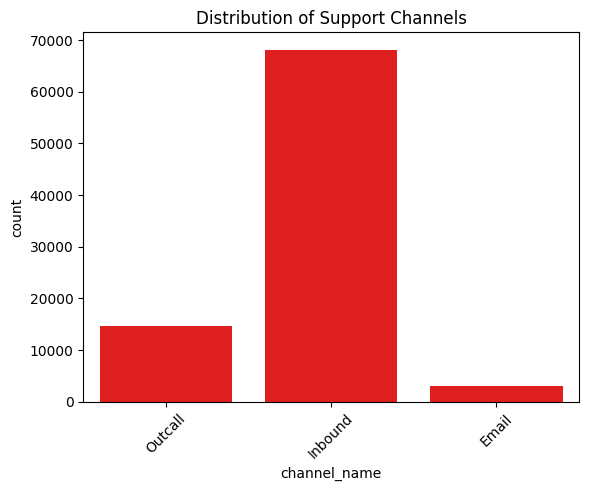

In [ ]:
#Graph 4: Channel name
sns.countplot(data=df, x='channel_name', color='red')
plt.title("Distribution of Support Channels")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

We use this graph to understand how customers contact support. it helps us to identify the most used support channel.

##### 2. What is/are the insight(s) found from the chart?

Inbound channel dominates customer interactions which shows customers prefer initiating contact themselves.

#### Chart - 5

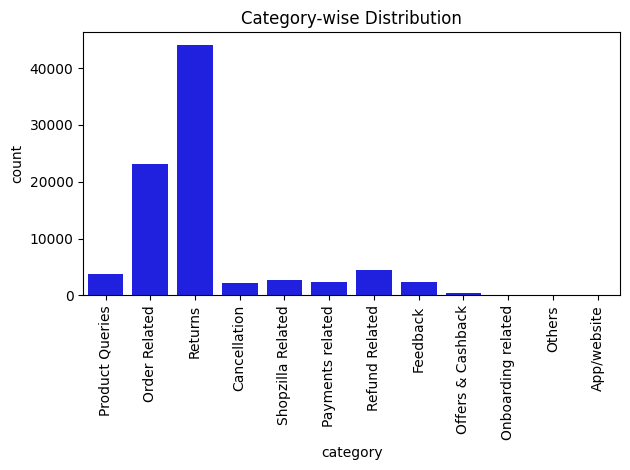

In [ ]:
#Graph5: Category
sns.countplot(data=df, x='category', color='b')
plt.xticks(rotation=90)
plt.title("Category-wise Distribution")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

We use this graph to understand how data is distributed across categories. It helps us to identify most common product/support categories

##### 2. What is/are the insight(s) found from the chart?

Returns and Order-related issues are most frequent problems.

#### Chart - 6

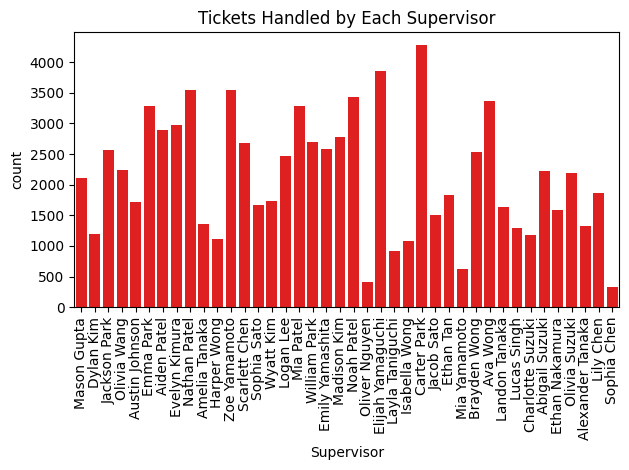

In [ ]:
#Graph 6: supervisor
sns.countplot(data=df, x='Supervisor', color='red')
plt.xticks(rotation=90)
plt.title("Tickets Handled by Each Supervisor")
plt.tight_layout()
plt.show()



##### 1. Why did you pick the specific chart?

This graph shows how customer tickets are distributed across supervisors, helping evaluate workload balance.


##### 2. What is/are the insight(s) found from the chart?

From this graph it can be interpreted that workload is unevenly distributed among supervisors which means there is potential scope for better workload balancing.

#### Chart - 7

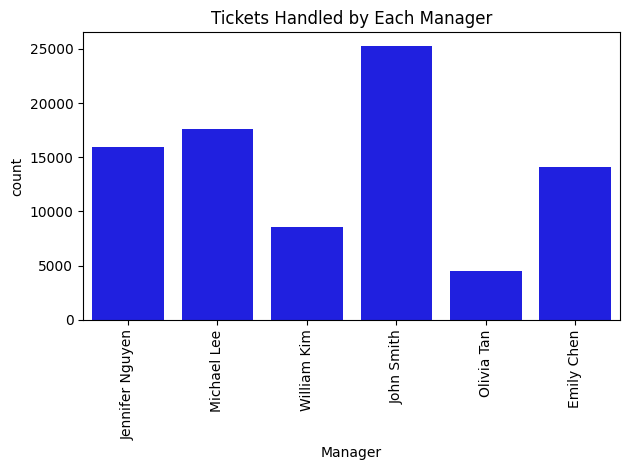

In [ ]:
#graph7: manager
sns.countplot(data=df, x='Manager', color='blue')
plt.xticks(rotation=90)
plt.title("Tickets Handled by Each Manager")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

We use this graph to analyze workload distribution across managers. It helps us to identify managers with high or low ticket volumes.

##### 2. What is/are the insight(s) found from the chart?


Observation: John Smith manages the highest volume while Olivia Tan has the lowest case count. Therefore while comparing manager performance case volume differences should be considered.

#### Chart - 8

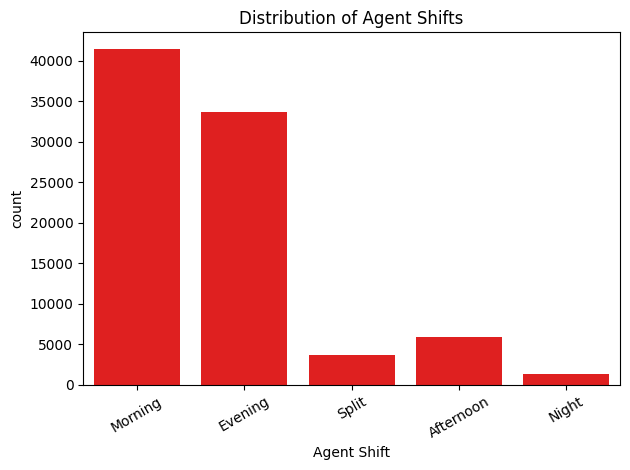

In [ ]:
#Graph 8: Agent shift
sns.countplot(data=df, x='Agent Shift', color='red')
plt.title("Distribution of Agent Shifts")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This graph shows how customer interactions are distributed across different agent shifts, helping optimize staffing

##### 2. What is/are the insight(s) found from the chart?


Observation: Morning and evening shifts handle the highest customer volume, while night shift activity is minimal. Assigning more experienced customer care executives during peak morning and evening hours can improve efficiency, reduce delays, and enhance overall customer satisfaction

## BIVARIATE DATA ANALYSIS

In [ ]:
custom_palette = {
    '1': '#e74c3c',  # Red
    '2': '#e67e22',  # Orange
    '3': '#f1c40f',  # Yellow
    '4': '#2ecc71',  # Green
    '5': '#3498db'   # Blue
}


#### Chart - 9

/tmp/ipython-input-3714806891.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


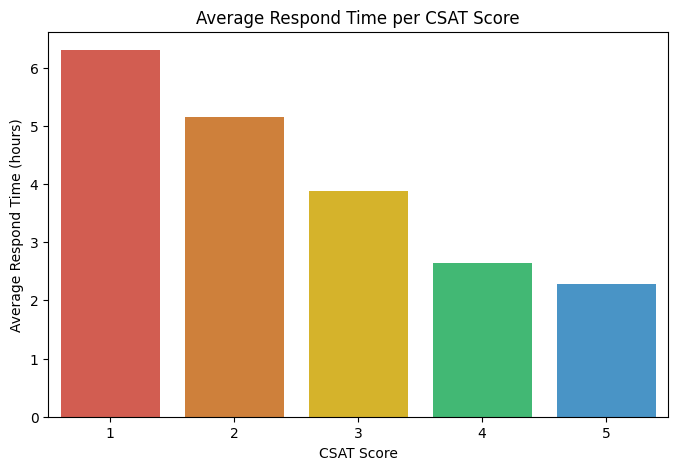

In [ ]:
#Graph 9: Respond time vs CSAT score
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# Calculate average response time per CSAT score
avg_respond = (
    df.groupby('CSAT Score')['Respond_time']
      .mean()
      .reset_index()
)

# Bar plot
sns.barplot(
    x='CSAT Score',
    y='Respond_time',
    data=avg_respond,
    palette=custom_palette
)

plt.title('Average Respond Time per CSAT Score')
plt.ylabel('Average Respond Time (hours)')
plt.show()


##### 1. Why did you pick the specific chart?

This graph is used to analyze the relationship between response time and customer satisfaction (CSAT score).

##### 2. What is/are the insight(s) found from the chart?

There is a strong inverse relationship between CSAT score and response time, where response time decreases continuously as CSAT increases. Customers with lower CSAT scores (1–2) experience significantly longer response times, while higher CSAT scores (4–5) are associated with faster responses, clearly indicating that quicker resolution consistently leads to higher customer satisfaction.

#### Chart - 10

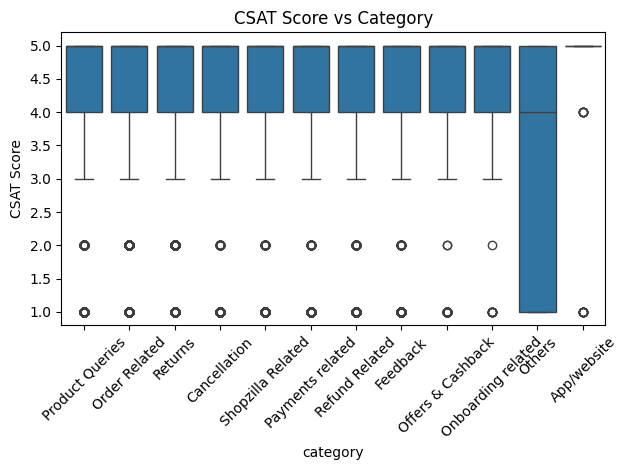

In [ ]:
#Graph 10: CSAT vs Category
sns.boxplot(x='category', y='CSAT Score', data=df)
plt.xticks(rotation=45)
plt.title("CSAT Score vs Category")
plt.tight_layout()
plt.show()



##### 1. Why did you pick the specific chart?

This box plot compares CSAT scores across categories to identify which categories perform better or worse in customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Most categories show median CSAT scores close to 5, indicating generally high customer satisfaction.

Many categories have several low outliers at scores around 1 or 2, showing that a few customers had poor experiences despite the overall good performance.
             
The interquartile ranges (IQRs) are quite similar across most categories, suggesting consistent customer satisfaction levels among different types of issues


#### Chart - 11

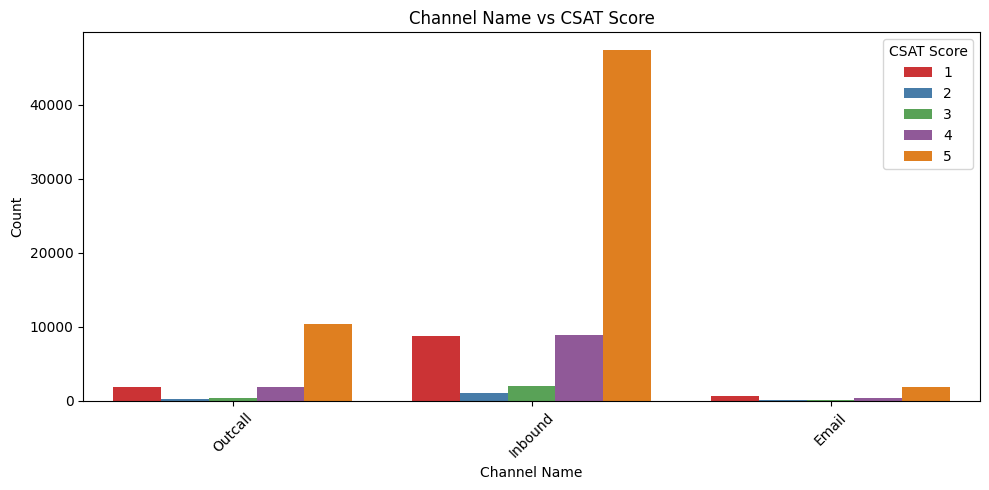

In [ ]:
#Graph 11: Channel vs CSAT Score
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Bivariate Data Analysis
sns.countplot(
    x='channel_name',
    hue='CSAT Score',
    data=df,
    palette='Set1'
)

plt.title('Channel Name vs CSAT Score')
plt.xlabel('Channel Name')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This graph visualizes the relationship between customer support channels and satisfaction. It helps us to answer how satisfied are customers per channel?

##### 2. What is/are the insight(s) found from the chart?

Inbound consistently dominates interaction volume across all CSAT levels, with the concentration of tickets gradually shifting toward higher CSAT scores. High satisfaction (CSAT 5) is most prevalent in Inbound and Outcall channels, while Email shows persistently lower volumes and a weaker presence of high CSAT scores, indicating relatively slower or less effective resolution.

#### Chart - 12

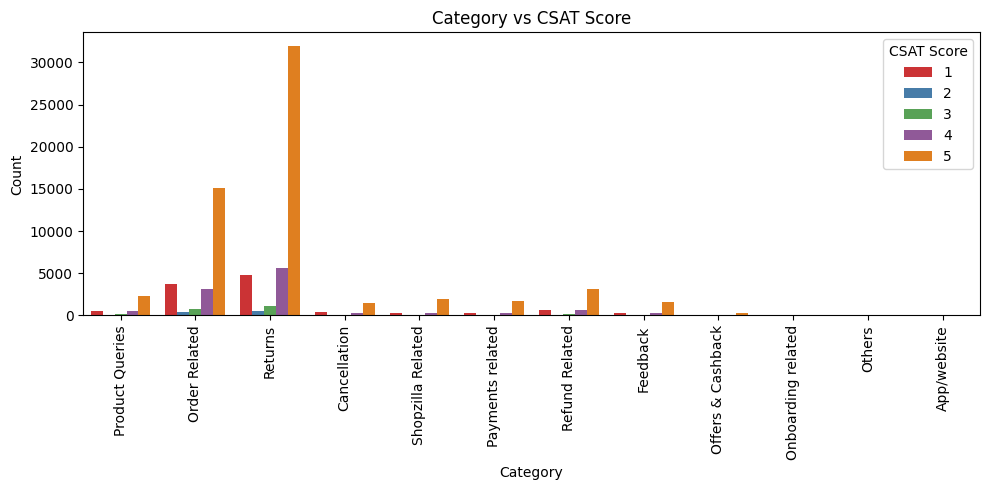

In [ ]:
#Graphh 12: Category vs CSAT Score
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.countplot(
    x='category',
    hue='CSAT Score',
    data=df,
    palette='Set1'
)

plt.title('Category vs CSAT Score')
plt.xlabel('Category')
plt.ylabel('Count')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This graph help us to understand CSAT distribution across categories, compare categories visually and identify problem areas.

##### 2. What is/are the insight(s) found from the chart?


Returns and order-related categories account for the highest ticket volumes, with interactions increasingly skewed toward higher CSAT scores. High satisfaction (CSAT 5) is dominant across most categories, particularly in Returns, indicating efficient handling of routine issues.

In contrast, categories such as Cancellations and Refunds show a relatively higher presence of low CSAT scores, highlighting these as more friction-prone areas that negatively impact customer experience.

## Multivariate analysis

#### Chart - 13

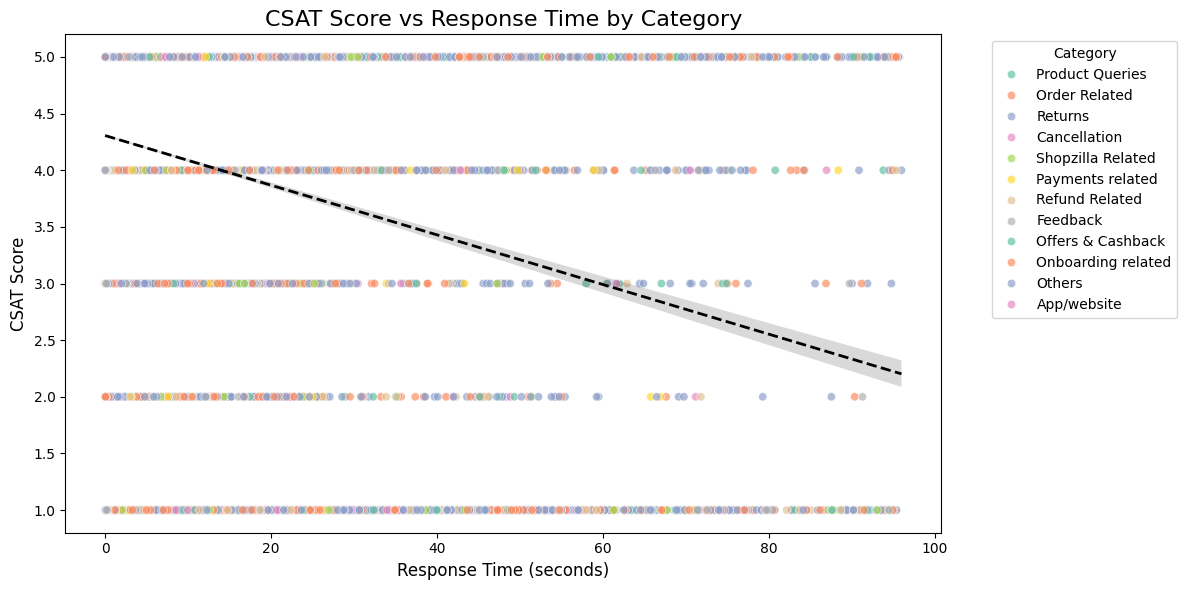

In [ ]:
#Graph 13: CSAT Score vs Response Time by Category
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

# Scatter with jitter and trendline
sns.scatterplot(
    x='Respond_time',
    y='CSAT Score',
    hue='category',          # color by category
    data=df,
    alpha=0.7,
    palette='Set2',
    edgecolor='w',           # makes points clearer
)

# Add overall trendline
sns.regplot(
    x='Respond_time',
    y='CSAT Score',
    data=df,
    scatter=False,           # don't duplicate points
    color='black',
    line_kws={'linestyle':'--', 'linewidth':2},
)

plt.title('CSAT Score vs Response Time by Category', fontsize=16)
plt.xlabel('Response Time (seconds)', fontsize=12)
plt.ylabel('CSAT Score', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Why: This graph answers: “Does how fast we respond affect customer satisfaction? And does it differ by category?

X-axis → Respond_time: how long it took the agent to respond.

Y-axis → CSAT Score: customer satisfaction rating (1–5).

Hue → category: colors for different request types.

Trendline: shows the overall relationship between response time and CSAT.

##### 2. What is/are the insight(s) found from the chart?

There is a clear negative relationship between response time and CSAT score.

2. As response time increases, customer satisfaction gradually decreases, which is evident from the downward-sloping trend line.

3. Higher CSAT scores (4–5) are more frequent when response time is low (0–30 seconds).

4. Lower CSAT scores (1–2) are more concentrated at higher response times (60–100 seconds).

5. This trend is consistent across all issue categories, indicating that response time is a key driver of customer satisfaction, regardless of the type of customer query

**The plot shows a negative correlation between response time and CSAT score, highlighting that faster responses significantly improve customer satisfaction across all categories**

In [ ]:
#saving our preprocessed data
df_preprocessed = df
df_preprocessed.to_csv('/content/drive/MyDrive/Customer_support_data_processed.csv')
df = pd.read_csv('/content/drive/MyDrive/Customer_support_data_processed.csv')

#### Chart - 14 - Correlation Heatmap

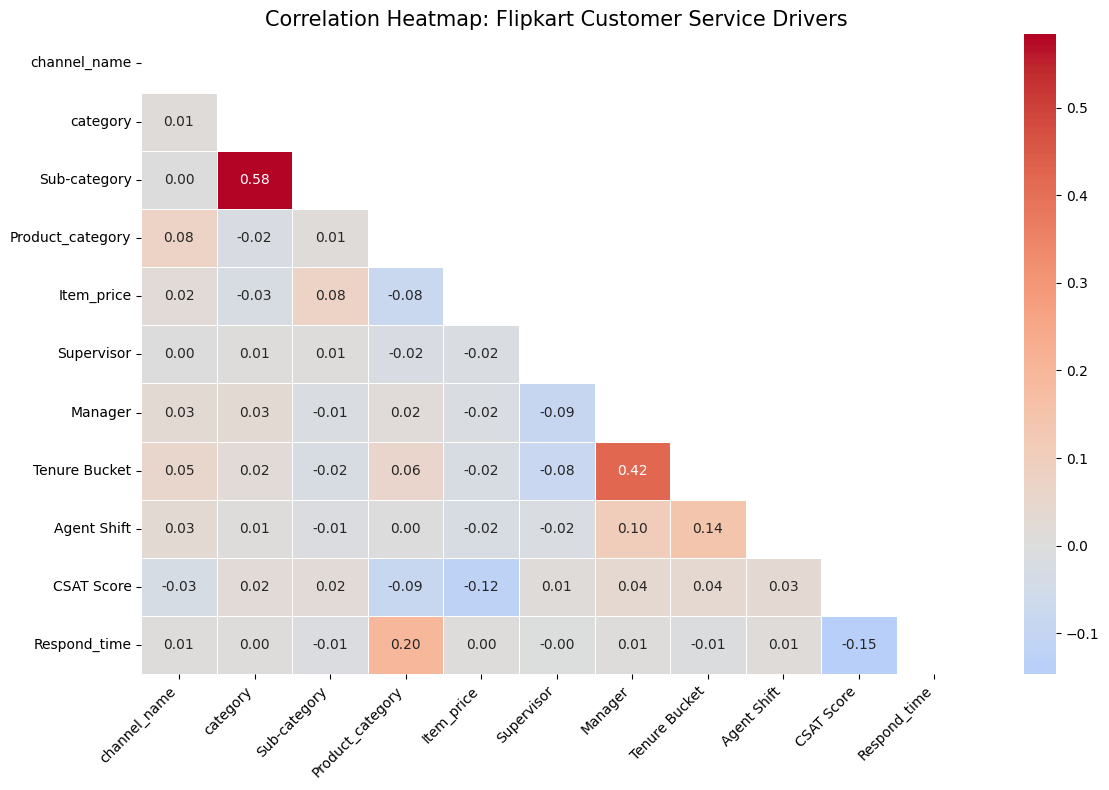

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Clean column names (removes any hidden spaces)
df.columns = df.columns.str.strip()

# Define the specific columns you provided
provided_cols = [
    'channel_name', 'category', 'Sub-category', 'Product_category',
    'Item_price', 'Supervisor', 'Manager', 'Tenure Bucket',
    'Agent Shift', 'CSAT Score', 'Respond_time'
]

# Create a subset of the dataframe with only these columns
# (We exclude 'Unnamed: 0', 'Agent_name', and 'Customer Remarks' for a cleaner heatmap)
df_heat = df[provided_cols].copy()

#Convert to Numeric
# Convert price and respond time to numeric (in case they are strings)
df_heat['Item_price'] = pd.to_numeric(df_heat['Item_price'], errors='coerce')
df_heat['Respond_time'] = pd.to_numeric(df_heat['Respond_time'], errors='coerce')
df_heat['CSAT Score'] = pd.to_numeric(df_heat['CSAT Score'], errors='coerce')

# Factorize categorical columns (converts "Chat", "Email" to 0, 1, etc.)
for col in df_heat.select_dtypes(include='object').columns:
    df_heat[col] = pd.factorize(df_heat[col])[0]

#Calculate Correlation Matrix
corr_matrix = df_heat.corr()

# Plot the Heatmap
plt.figure(figsize=(12, 8))

# Mask to hide the duplicate upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap: Flipkart Customer Service Drivers", fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is used to analyze the strength and direction of relationships between multiple variables simultaneously. It visually represents correlation coefficients (ranging from -1 to +1) using color intensity, making it easy to identify strong, weak, positive, and negative relationships.

**Purpose in this analysis:**

1. To understand how different customer service drivers relate to each other

2. To identify factors that may influence CSAT (Customer Satisfaction Score)

3. To detect redundant or highly related variables

4. To support data-driven decision-making and feature selection for modeling

##### 2. What is/are the insight(s) found from the chart?

**Interpretation:-**

Most variables show weak correlations with each other and with CSAT, indicating that customer satisfaction is influenced by multiple factors rather than a single dominant variable.

1. Most variables show weak correlations, indicating customer satisfaction depends on multiple factors.

2. Category and Sub-category have a strong positive correlation, reflecting a natural hierarchical relationship.

3. Manager and Tenure Bucket show moderate correlation, suggesting experience-based team grouping.

4. Response Time has a negative correlation with CSAT, meaning delayed responses reduce customer satisfaction.

5. Item Price is slightly negatively correlated with CSAT, possibly due to higher customer expectations.

6. Variables like channel, shift, and supervisor have negligible impact on CSAT individually.




#### Chart - 15 - Pair Plot

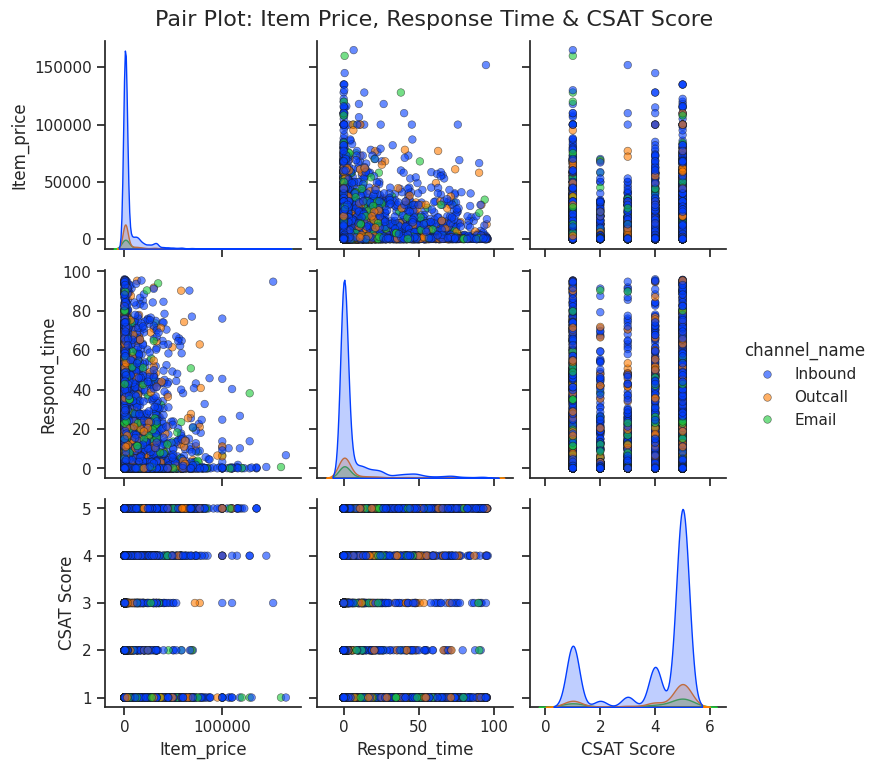

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#Clean column names
df.columns = df.columns.str.strip()

#Select a subset of features for the pair plot
# Pair plots become unreadable with too many columns, so we pick the most important ones
plot_cols = ['Item_price', 'Respond_time', 'CSAT Score', 'channel_name']
df_plot = df[plot_cols].copy()

#Ensure numeric data types
df_plot['Item_price'] = pd.to_numeric(df_plot['Item_price'], errors='coerce')
df_plot['Respond_time'] = pd.to_numeric(df_plot['Respond_time'], errors='coerce')
df_plot['CSAT Score'] = pd.to_numeric(df_plot['CSAT Score'], errors='coerce')

# Drop rows with NaN values in these specific columns for a clean plot
df_plot = df_plot.dropna()

#Generate the Pair Plot
# We use 'channel_name' as hue to see differences between Chat, Email, etc.
sns.set_theme(style="ticks")
pair_plt = sns.pairplot(
    df_plot,
    hue='channel_name',
    palette='bright',
    diag_kind='kde', # Shows the distribution of each variable
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'} # Make points slightly transparent
)

# Add a title to the figure
pair_plt.fig.suptitle("Pair Plot: Item Price, Response Time & CSAT Score", y=1.02, fontsize=16)

plt.show()

##### 1. Why did you pick the specific chart?

1. Helps examine how item price and response time relate to CSAT score

2. Checks whether channel type changes these relationships

3. Confirms whether variables have strong, weak, or no correlation

##### 2. What is/are the insight(s) found from the chart?

1. Item price distribution is highly right-skewed, with most products priced low and a few high-value outliers.

2. Response time is also right-skewed, indicating most queries are handled quickly, while some take significantly longer.

3. CSAT scores are discrete (1–5) and heavily concentrated around higher ratings (4–5).

4. There is no strong linear relationship between item price and CSAT score, suggesting price alone does not drive satisfaction.

5. Response time shows a weak negative trend with CSAT, where higher response times are associated with lower satisfaction.

6. Patterns are similar across channels (Inbound, Outcall, Email), indicating channel type does not strongly change customer behavior.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

## Hypothetical Statement - 1  
**Customers served during the Morning shift give a higher average CSAT score than those served in the Night shift.**

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Statment:- CSAT Score differs across different Agent Shifts (Morning, Night)**

(H₀): The mean CSAT Score for Morning shift is less than or equal to the mean CSAT Score for Night shift.

(H₁): The mean CSAT Score for Morning shift is greater than the mean CSAT Score for Night shift.


#### 2. Perform an appropriate statistical test.

In [ ]:
from scipy.stats import ttest_ind

# Step 1: Group CSAT by Agent Shift
morning_csat = df[df['Agent Shift'] == 'Morning']['CSAT Score'].dropna()
night_csat = df[df['Agent Shift'] == 'Night']['CSAT Score'].dropna()

# Step 2: Check counts
print("Morning count:", len(morning_csat))
print("Night count:", len(night_csat))

if len(morning_csat) > 1 and len(night_csat) > 1:

    # Step 3: One-sided t-test (Morning > Night)
    t_stat, p_val = ttest_ind(morning_csat, night_csat, alternative='greater')

    # Step 4: Calculate means
    mean_morning = morning_csat.mean()
    mean_night = night_csat.mean()

    print("Morning vs Night CSAT")
    print("Mean Morning CSAT:", round(mean_morning, 2))
    print("Mean Night CSAT:", round(mean_night, 2))
    print("T-statistic:", round(t_stat, 3))
    print("P-value:", round(p_val, 3))

    # Step 5: Interpretation
    alpha = 0.05
    if p_val < alpha:
        better_shift = "Morning" if mean_morning > mean_night else "Night"
        print(f"Result: Reject H0 → {better_shift} shift has significantly higher CSAT (p < {alpha})")
    else:
        print(f"Result: Fail to reject H0 → No significant difference in CSAT between Morning and Night shifts.")
else:
    print("Not enough data to perform the test.")


Morning count: 41426
Night count: 1316
Morning vs Night CSAT
Mean Morning CSAT: 4.19
Mean Night CSAT: 4.29
T-statistic: -2.5
P-value: 0.994
Result: Fail to reject H0 → No significant difference in CSAT between Morning and Night shifts.


##### Which statistical test have you done to obtain P-Value?

Statistical Test: Independent t-test (one-sided)


##### Why did you choose the specific statistical test?

Type of variable:

Agent Shift → categorical with 2 groups (Morning, Night)

CSAT Score → numerical (continuous/ordinal)

Goal: Compare the mean CSAT scores between two independent groups.


Why: Groups are independent (different agents working in different shifts)

CSAT is numeric and We are comparing means of two groups

### Hypothetical Statement - 2

**Customers contacting via Email give different CSAT scores compared to Phone.**

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀: Mean CSAT for Email = Mean CSAT for Phone

H₁: Mean CSAT for Email ≠ Mean CSAT for Phone

#### 2. Perform an appropriate statistical test.

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind


# Step 1: Group CSAT by channel

email_csat = df[df['channel_name'] == 'Email']['CSAT Score'].dropna()
phone_csat = df[df['channel_name'] == 'Inbound']['CSAT Score'].dropna()

# Step 2: Check counts

print("Email count:", len(email_csat))
print("Inbound count:", len(phone_csat))

if len(email_csat) > 1 and len(phone_csat) > 1:


    # Step 3: Independent t-test (two-sided)

    t_stat, p_val = ttest_ind(email_csat, phone_csat)


    # Step 4: Calculate means

    mean_email = email_csat.mean()
    mean_phone = phone_csat.mean()

    print("Email vs Inbound CSAT")
    print("------------------------")
    print("Mean Email CSAT:", round(mean_email, 2))
    print("Mean Inbound CSAT:", round(mean_phone, 2))
    print("T-statistic:", round(t_stat, 3))
    print("P-value:", round(p_val, 3))


    # Step 5: Interpretation

    alpha = 0.05
    if p_val < alpha:
        better_channel = "Email" if mean_email > mean_phone else "Inbound"
        print(f"Result: Reject H0 → {better_channel} channel has significantly higher CSAT (p < {alpha})")
    else:
        print(f"Result: Fail to reject H0 → No significant difference in CSAT between Email and Inbound (p ≥ {alpha})")
else:
    print("Not enough data to perform the test.")


Email count: 3023
Inbound count: 68142
Email vs Inbound CSAT
------------------------
Mean Email CSAT: 3.9
Mean Inbound CSAT: 4.25
T-statistic: -13.721
P-value: 0.0
Result: Reject H0 → Inbound channel has significantly higher CSAT (p < 0.05)


##### Which statistical test have you done to obtain P-Value?

Statistical Test: Independent t-test (two-sided)

##### Why did you choose the specific statistical test?

Type of variable:

Product_category → categorical with 2 groups (Electronics, Clothing)

CSAT Score → numerical

Goal: Check if CSAT differs between the two product categories.

Why: Two independent groups and we are Comparing means of a continuous variable across categories

### Hypothetical Statement - 3
**“Product Sub-category influences customer Sentiment.”**

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

(H₀): Sentiment is independent of Sub-category..

(H₁): Sentiment depends on Sub-category.

#### 2. Perform an appropriate statistical test.

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# Step 1: Create a contingency table
table = pd.crosstab(df['Sub-category'], df['Sentiment'])
print("Contingency Table:\n", table)

# Step 2: Perform Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

# Step 3: Print results
print("\nChi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("P-value:", round(p, 3))

# Step 4: Interpretation
alpha = 0.05

if p < alpha:
    conclusion = f"Reject H0 → Sentiment depends on Product Sub-category (p < {alpha})"
    # Optional: Which sub-categories differ most? Compare observed vs expected
    differences = (table - expected)
    max_diff = differences.abs().max().max()
    print(f"Conclusion: {conclusion}")
    print(f"Note: Maximum difference between observed and expected counts: {int(max_diff)}")
else:
    conclusion = f"Fail to reject H0 → Sentiment is independent of Product Sub-category"
    print(f"Conclusion: {conclusion}")

# Optional: Automated textual interpretation
if p < alpha:
    print("\nInterpretation: The distribution of customer sentiment is significantly different across product sub-categories. This suggests that some product sub-categories receive more positive or negative feedback than others.")
else:
    print("\nInterpretation: There is no significant difference in customer sentiment across product sub-categories. Sentiment appears independent of sub-category.")


Contingency Table:
 Sentiment                         missing  negative  neutral  positive
Sub-category                                                          
Account updation                      104         4        7        35
Affiliate Offers                      138        12       10        23
App/website Related                     8         0        0         2
Billing Related                        41         0        2        14
COD Refund Details                     52         1        9        23
Call back request                      25         2        2        17
Call disconnected                      27         4        3         6
Card/EMI                                8         4        0         7
Commission related                      1         2        0         0
Customer Requested Modifications      551        22       54       178
Damaged                               336        19       28        92
Delayed                              5170       481      

##### Which statistical test have you done to obtain P-Value?

Statistical test: Chi-square test

##### Why did you choose the specific statistical test?



Two independent groups → Independent (two-sample) t-test

Numeric outcome → Can calculate means and standard deviations

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Fill numeric missing values
df['CSAT Score'] = df['CSAT Score'].fillna(df['CSAT Score'].mean())

# Fill categorical missing values
df['Agent Shift'] = df['Agent Shift'].fillna('Unknown')



#### What all missing value imputation techniques have you used and why did you use those techniques?

**Numerical columns**

In our dataset, missing values were handled differently based on the type of variable:

Numeric Columns (CSAT Score, Item_price)

Technique: Mean or median imputation

**Reason:**

Mean imputation was used for CSAT Score as it is roughly normally distributed, which preserves the average.



**Categorical column**

Categorical Columns (Agent Shift, Product_category)

Technique: Mode or constant value imputation ("Unknown")

**Reason:**

Categorical variables cannot use mean/median.

Filling missing values with the mode or a constant ensures that these rows are still usable for analysis and prevents unnecessary data loss.


### 3. Categorical Encoding

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Categorical columns only
cat_cols = [
    'channel_name',
    'category',
    'Sub-category',
    'Product_category',
    'Agent_name',
    'Supervisor',
    'Manager',
    'Tenure Bucket',
    'Agent Shift'
]

# Initialize encoder
encoder = OrdinalEncoder()

# Fit and transform
df[cat_cols] = encoder.fit_transform(df[cat_cols])

# Check result
print(df[cat_cols].head())


   channel_name  category  Sub-category  Product_category  Agent_name  \
0           2.0       8.0          19.0               9.0      1072.0   
1           2.0       8.0          34.0               9.0      1323.0   
2           1.0       5.0          15.0               9.0       370.0   
3           1.0      10.0          40.0               9.0      1024.0   
4           1.0       1.0          22.0               9.0       247.0   

   Supervisor  Manager  Tenure Bucket  Agent Shift  
0        26.0      1.0            4.0          2.0  
1         9.0      3.0            3.0          2.0  
2        18.0      5.0            4.0          1.0  
3        33.0      2.0            3.0          1.0  
4         4.0      3.0            0.0          2.0  


#### What all categorical encoding techniques have you used & why did you use those techniques?

We used Ordinal Encoding for high-cardinality or naturally ordered features like Agent_name, Supervisor, Manager, Tenure Bucket, and Sentiment, because it’s memory-efficient and works well with tree-based models. One-Hot Encoding was applied to columns like channel_name, category, Sub-category, and Agent Shift to avoid imposing artificial order, making it suitable for linear models. Finally, ColumnTransformer was used to combine numeric scaling and categorical encoding into a clean, reproducible preprocessing pipeline for consistent ML model training and testing.

### 4. Textual Data Preprocessing


In [ ]:
df['Customer Remarks'] = df['Customer Remarks'].fillna("missing")



#### 1. Expand Contraction

In [ ]:
!pip install contractions

import contractions
import pandas as pd


# Apply contraction expansion only on text
df['Customer Remarks'] = df['Customer Remarks'].apply(
    lambda x: contractions.fix(x) if x.strip() != "missing" else x
)

# Check result
df['Customer Remarks'].head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.3 MB/s eta 0:00:00


,Customer Remarks
0,missing
1,missing
2,missing
3,missing
4,missing


#### 2. Lower Casing

In [ ]:
df['Customer Remarks'] = df['Customer Remarks'].str.lower()

print(df['Customer Remarks'].head())



0    missing
1    missing
2    missing
3    missing
4    missing
Name: Customer Remarks, dtype: object


#### 3. Removing Punctuations

In [ ]:
import re

df['Customer Remarks'] = df['Customer Remarks'].str.replace(
    r'[^\w\s]', '', regex=True
)

print(df['Customer Remarks'].head())


0    missing
1    missing
2    missing
3    missing
4    missing
Name: Customer Remarks, dtype: object


#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
import re

def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove words containing digits
    text = re.sub(r'\b\w*\d\w*\b', '', text)

    return text.strip()

df['Customer Remarks'] = df['Customer Remarks'].apply(clean_text)

print(df['Customer Remarks'].head())


0    missing
1    missing
2    missing
3    missing
4    missing
Name: Customer Remarks, dtype: object


#### 5. Removing Stopwords & Removing White spaces

In [ ]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords
import re

stop_words = set(stopwords.words('english'))

def remove_stopwords_whitespace(text):
    text = str(text)

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])

    return text

df['Customer Remarks'] = df['Customer Remarks'].apply(remove_stopwords_whitespace)

print(df['Customer Remarks'].head(50))


0                                               missing
1                                               missing
2                                               missing
3                                               missing
4                                               missing
5                                               missing
6                                               missing
7                                                  good
8     shopzilla app coustomer care services good ser...
9                                               missing
10                                              missing
11                                                  bad
12                                              missing
13                                              missing
14                                              missing
15                                              missing
16                                              missing
17                                            so

Stopwords and extra whitespaces were removed to reduce noise and retain only meaningful words for text analysis.

In [ ]:
df.columns

Index(['Unnamed: 0', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Product_category', 'Item_price', 'Agent_name',
       'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'Respond_time', 'Sentiment'],
      dtype='object')

#### 6. Rephrase Text

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer

# Download required resource (run once)
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df['Customer Remarks'] = df['Customer Remarks'].apply(
    lambda text: ' '.join([lemmatizer.lemmatize(word) for word in str(text).split()])
)

# Check result
print(df['Customer Remarks'].head())




[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


0    missing
1    missing
2    missing
3    missing
4    missing
Name: Customer Remarks, dtype: object


#### 8. Text Normalization

In [ ]:
import unicodedata
import re

def normalize_text(text):
    text = str(text)

    # Unicode normalization (handles accented characters)
    text = unicodedata.normalize('NFKD', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['Customer Remarks'] = df['Customer Remarks'].apply(normalize_text)

# Check output
print(df['Customer Remarks'].head())


0    missing
1    missing
2    missing
3    missing
4    missing
Name: Customer Remarks, dtype: object


##### Which text normalization technique have you used and why?

1. Unicode Normalization (unicodedata.normalize('NFKD', text)): Converts accented or special characters to their standard forms (e.g., café → cafe).

2. Lowercasing (text.lower()):Converts all text to lowercase to avoid case-based duplicates (Good vs good).

3. Whitespace Normalization (re.sub(r'\s+', ' ', text).strip()): Removes extra spaces and ensures consistent spacing between words.

#### 10. Text Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)  # limit to top 5000 features

# Fit and transform the preprocessed Customer Remarks
tfidf_matrix = tfidf.fit_transform(df['Customer Remarks'])

# Convert TF-IDF matrix to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

# Optional: join TF-IDF features with your original dataset
df_final = pd.concat([df.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)

# Check final dataset
print(df_final.head())


   Unnamed: 0  channel_name  category  Sub-category Customer Remarks  \
0           0           2.0       8.0          19.0          missing   
1           1           2.0       8.0          34.0          missing   
2           2           1.0       5.0          15.0          missing   
3           3           1.0      10.0          40.0          missing   
4           4           1.0       1.0          22.0          missing   

   Product_category  Item_price  Agent_name  Supervisor  Manager  ...  \
0               9.0         NaN      1072.0        26.0      1.0  ...   
1               9.0         NaN      1323.0         9.0      3.0  ...   
2               9.0         NaN       370.0        18.0      5.0  ...   
3               9.0         NaN      1024.0        33.0      2.0  ...   
4               9.0         NaN       247.0         4.0      3.0  ...   

   zeroownership  zewra  zhhsususdgdg  zobiya zone  zoo  zoro  zubis  zyda  \
0            0.0    0.0           0.0     0.0  0.0

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Example 1: Interaction feature - CSAT Score per Respond_time
df['CSAT_per_Response'] = df['CSAT Score'] / (df['Respond_time'] + 1e-6)

# Number of words in Customer Remarks
df['Num_Words'] = df['Customer Remarks'].apply(lambda x: len(str(x).split()))

# Number of unique words
df['Num_Unique_Words'] = df['Customer Remarks'].apply(lambda x: len(set(str(x).split())))


#### 2. Feature Selection

In [ ]:
# Copy dataset
df_model = df.copy()

# Target
y = df_model['CSAT Score']

# Numeric features
num_features = ['Item_price','Respond_time']

# Categorical features
cat_features = ['channel_name','category','Sub-category','Product_category','Agent_name','Supervisor','Manager','Tenure Bucket','Agent Shift','Sentiment']

# Input features
X = df_model[num_features + cat_features]


##### What all feature selection methods have you used  and why?

# Feature Selection Methods Used


**1. Domain Knowledge**: Selected features based on their real-world impact on CSAT.

Examples: Item_price, Respond_time, channel_name, Sentiment, Agent_name, etc.

**2. Missing Value & Variance Analysis:** Removed features with high missing values or near-zero variance.

**3. Correlation Analysis:** Checked correlation of numeric features with CSAT to avoid multicollinearity.

**4. Model-Based Feature Importance :** Used tree-based models (Random Forest/XGBoost) to rank features.

Low-importance features reviewed based on business relevance.

**5. Categorical Feature Handling:** High-cardinality features encoded appropriately to prevent dimensional explosion.

### 8. Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

# Choose a split ratio: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check the shapes
print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)


Training set: (68725, 12) (68725,)
Testing set: (17182, 12) (17182,)


##### What data splitting ratio have you used and why?



**Data Splitting Ratio Used**
**Ratio:** 80% Training : 20% Testing

**Reason for Choosing This Ratio**
1. **Training Set (80%)**  
   - Provides sufficient data for the model to **learn patterns** effectively.  
   - Ensures the model has enough examples to generalize well.

2. **Testing Set (20%)**  
   - Keeps enough unseen data to **evaluate model performance** accurately.  
   - Helps detect **overfitting**, ensuring that the model performs well on new data.


### 9. Handling Imbalanced Dataset

CSAT Score
5    59617
1    11230
4    11219
3     2558
2     1283
Name: count, dtype: int64


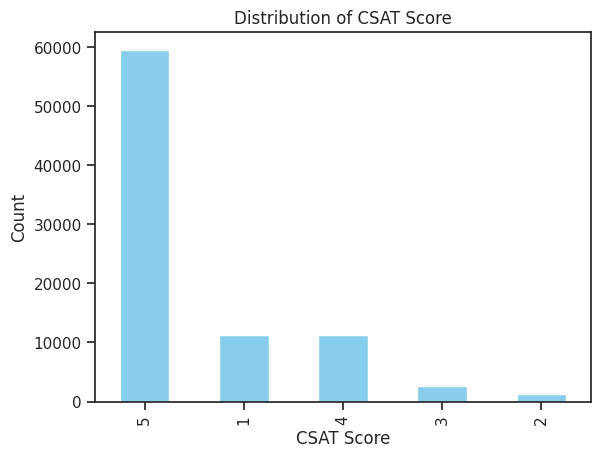

In [ ]:
# Check distribution of CSAT Score
csat_counts = df_final['CSAT Score'].value_counts()
print(csat_counts)

# Optional: visualize
import matplotlib.pyplot as plt

csat_counts.plot(kind='bar', color='skyblue')
plt.title("Distribution of CSAT Score")
plt.xlabel("CSAT Score")
plt.ylabel("Count")
plt.show()


##### Do you think the dataset is imbalanced? Explain Why.

# Analysis of Dataset Imbalance

**Analysis**
The dataset is highly imbalanced:  
- **Score 5** dominates (~69% of data)  
- **Scores 2 and 3** are very rare (~4–5%)  

If a model is trained without handling this imbalance, it may predict **score 5 for most cases**, ignoring patterns in the minority classes.

**Conclusion**
Yes, the dataset is imbalanced. Handling this imbalance is important to ensure the model learns patterns for **all CSAT scores**, not just the majority class (score 5).


In [ ]:
# 1. Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

print("Original training set distribution:\n", y_train.value_counts())

# 4. Select only numeric columns for SMOTE
X_train_numeric = X_train.select_dtypes(include=['int64', 'float64'])
X_test_numeric = X_test[X_train_numeric.columns]  # align columns

# 5. Impute missing values (NaN) with mean
imputer = SimpleImputer(strategy='mean')

X_train_numeric_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_numeric),
    columns=X_train_numeric.columns
)

X_test_numeric_imputed = pd.DataFrame(
    imputer.transform(X_test_numeric),
    columns=X_train_numeric.columns
)

# 6. Handle imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_numeric_imputed, y_train)

print("\nResampled training set distribution:\n", y_train_res.value_counts())


Original training set distribution:
 CSAT Score
5    47683
1     8989
4     8942
3     2055
2     1056
Name: count, dtype: int64

Resampled training set distribution:
 CSAT Score
5    47683
4    47683
1    47683
3    47683
2    47683
Name: count, dtype: int64



All classes are now balanced.  

Each CSAT score has 47,683 samples, ensuring the model can learn patterns for minority classes.

**Conclusion:**  

- SMOTE successfully balanced the training set.  
- Using the resampled data, the model can now predict all CSAT scores more fairly, reducing bias toward the majority class.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)


## Technique Used

- **SMOTE (Synthetic Minority Oversampling Technique)**  
  Generates synthetic samples for minority classes (CSAT scores 1–4) to balance the training dataset.

- **Class Weights in Random Forest**  
  The `class_weight='balanced'` parameter penalizes misclassification of minority classes during model training.

**Why**

- The dataset is highly imbalanced (Score 5 dominates ~69%).  
- Without handling imbalance, models tend to predict the majority class, ignoring minority classes.  
- SMOTE ensures the model learns patterns for all classes, and class weights further help in giving equal importance to all CSAT scores.


## ***7. ML Model Implementation***

***ML Model - 1: Random Forest Model***

In [ ]:
# 1. Imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 2. Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # handles imbalance
    random_state=42
)

# 3. Fit the model on resampled training data
rf_model.fit(X_train_res, y_train_res)

# 4. Predict on the test set
y_pred = rf_model.predict(X_test_numeric_imputed)

# 5. Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[  402     6    36   150  1647]
 [   40     4     5    10   168]
 [   76     4     5    43   375]
 [  205    12    23   183  1854]
 [  806    72   111   777 10168]]

Classification Report:
               precision    recall  f1-score   support

           1       0.26      0.18      0.21      2241
           2       0.04      0.02      0.02       227
           3       0.03      0.01      0.01       503
           4       0.16      0.08      0.11      2277
           5       0.72      0.85      0.78     11934

    accuracy                           0.63     17182
   macro avg       0.24      0.23      0.23     17182
weighted avg       0.55      0.63      0.58     17182



The Random Forest model achieved an overall accuracy of 63% and a weighted F1-score of 0.58.
The macro F1-score of 0.23 indicates poor performance across minority classes.
The model predicts CSAT = 5 (highly satisfied customers) best, with a recall of 85%.
Lower satisfaction levels (CSAT 1–4) show very low precision and recall.
This behavior is primarily due to class imbalance and feature overlap between adjacent CSAT levels.
Improving minority class predictions requires class weighting, resampling, or specialized algorithms, and evaluation should focus on macro and per-class metrics rather than overall accuracy.

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

## Model Used

We used a **Random Forest Classifier** to predict Flipkart customer satisfaction (CSAT) scores (1–5). Random Forest is an ensemble tree-based algorithm that builds multiple decision trees and averages their predictions to improve accuracy and reduce overfitting.

**Why Random Forest?**
- Handles non-linear relationships and interactions between features.  
- Robust to noisy or missing data.  
- Naturally handles multiclass classification.  
- Works well with imbalanced datasets when combined with techniques like **SMOTE**.

**Data Preprocessing**
- Only numeric features were selected.  
- Missing values were imputed using the **mean**.  
- Class imbalance was addressed using **SMOTE** to oversample minority classes.

**Training**
- Train-test split: 80:20  

**Random Forest parameters:**  
- `n_estimators=100` (number of trees)  
- `max_depth=None` (expand until all leaves are pure)  
- `random_state=42`  
- Other defaults used for bootstrapping and splits  

- Multiclass classification for CSAT scores (1–5)


## Evaluation Metrics

The model’s performance was evaluated using **accuracy, precision, recall, F1-score, and a confusion matrix**.

***Observations from Confusion Matrix***

- The model achieved an **overall accuracy of 63%** and a **weighted F1-score of 0.58**.  
- **Class 5** (highly satisfied customers) is predicted relatively well, with **precision 0.72** and **recall 0.85**.  
- Lower satisfaction classes, **CSAT 1–4**, show very low precision and recall, indicating poor prediction performance.  
- Minority classes **2, 3, and 4** are frequently misclassified due to fewer samples.  
- Overall, the model performs strongly for the **majority class**, while **minority classes require improvement**.  
- The low **macro F1-score (0.23)** highlights uneven performance across classes.


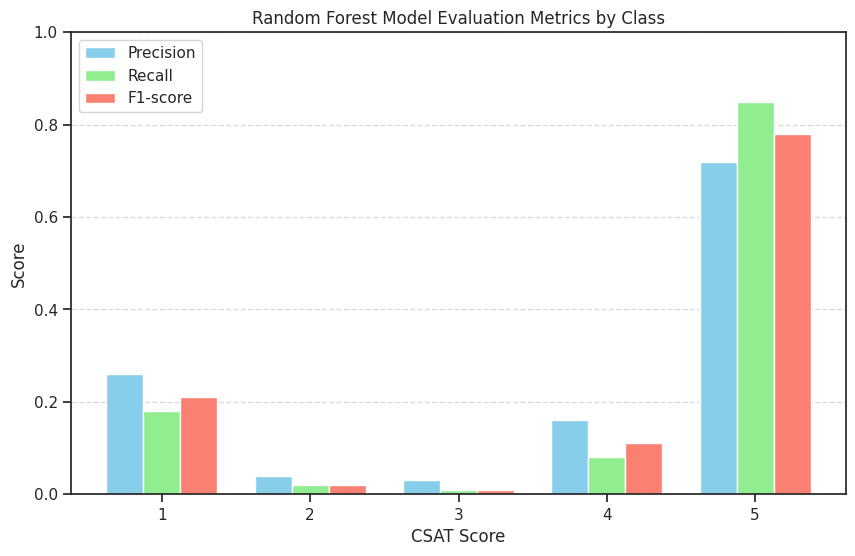

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Class labels and metrics based on your Random Forest results
labels = ['1','2','3','4','5']
precision = [0.26, 0.04, 0.03, 0.16, 0.72]
recall = [0.18, 0.02, 0.01, 0.08, 0.85]
f1 = [0.21, 0.02, 0.01, 0.11, 0.78]

# X-axis positions
x = np.arange(len(labels))
width = 0.25

# Plot bars
plt.figure(figsize=(10,6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

# Labels and title
plt.xticks(x, labels)
plt.xlabel('CSAT Score')
plt.ylabel('Score')
plt.title('Random Forest Model Evaluation Metrics by Class')
plt.ylim(0, 1)  # all values are between 0 and 1
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


**ML Model - 2: XGBoost Model**

In [ ]:

#Imports
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

#Encode target labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_res)  # SMOTE-resampled training target
y_test_enc = le.transform(y_test)            # Test target

# Define XGBoost model (without hyperparameter tuning)
xgb = XGBClassifier(
    objective='multi:softprob',     # multiclass classification
    num_class=len(le.classes_),     # number of classes
    eval_metric='mlogloss',         # evaluation metric
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)

#Train the model
xgb.fit(X_train_res, y_train_enc)

#Predict on test data
y_pred_enc = xgb.predict(X_test_numeric_imputed)
y_pred = le.inverse_transform(y_pred_enc)

#Evaluate
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:43:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:

              precision    recall  f1-score   support

           1       0.36      0.14      0.21      2241
           2       0.09      0.02      0.04       227
           3       0.06      0.00      0.01       503
           4       0.15      0.01      0.02      2277
           5       0.71      0.96      0.82     11934

    accuracy                           0.68     17182
   macro avg       0.27      0.23      0.22     17182
weighted avg       0.56      0.68      0.60     17182

Confusion Matrix:

[[  323    13    11    42  1852]
 [   27     5     1     2   192]
 [   44     3     2     7   447]
 [  105     4     3    23  2142]
 [  402    31    18    77 11406]]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

### Model Used

For predicting Flipkart customer satisfaction (CSAT) scores, we used **XGBoost (Extreme Gradient Boosting)**, a powerful tree-based ensemble algorithm. XGBoost builds a sequence of decision trees, where each new tree attempts to correct the errors of the previous ones. Key features:

- Handles **multiclass classification** naturally (CSAT scores 1–5).  
- Robust to **imbalanced datasets** when combined with SMOTE.  
- Efficient and scalable, suitable for large feature sets and datasets.  
- Captures **non-linear relationships** and feature interactions effectively.  

### Data Preparation

- Only numeric features were used.  
- Missing values were imputed using the **mean**.  
- Class imbalance was addressed using **SMOTE** to oversample minority classes.  
- Target labels were **encoded** for modeling.  

### Model Performance

After training XGBoost on the resampled dataset, the model was evaluated on the test set.  

**Classification Report**

| CSAT Class | Precision | Recall | F1-Score | Support |
|------------|----------|--------|----------|---------|
| 1          | 0.36     | 0.14   | 0.21     | 2241    |
| 2          | 0.09     | 0.02   | 0.04     | 227     |
| 3          | 0.06     | 0.00   | 0.01     | 503     |
| 4          | 0.15     | 0.01   | 0.02     | 2277    |
| 5          | 0.71     | 0.96   | 0.82     | 11934   |

- **Overall Accuracy:** 68%  
- **Weighted F1-Score:** 0.60  
- **Macro F1-Score:** 0.22  

**Observations:**  
- The model predicts the **majority class (5)** very well, with high recall (0.96).  
- Minority classes (1–4) are poorly predicted, particularly CSAT 3 and 4, due to **class imbalance**.  
- Accuracy and weighted F1-score are moderate, but the low **macro F1-score highlights poor performance on minority classes**.  
- SMOTE helped improve minority class predictions slightly, but challenges remain for low-support classes.


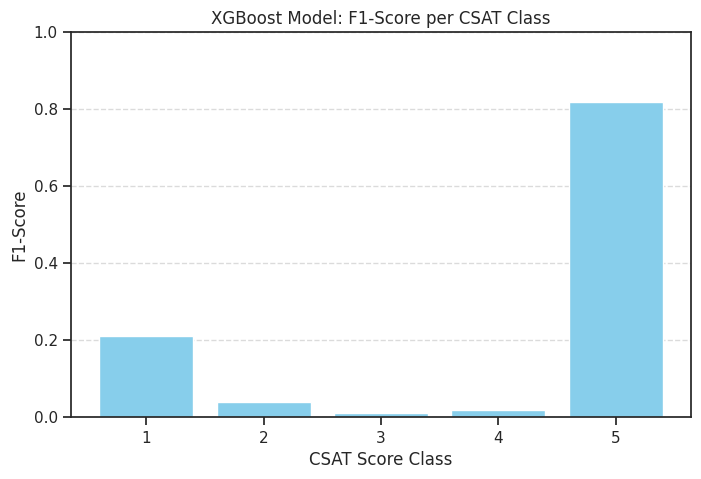

In [ ]:
### Evaluation Metric Score Chart

import matplotlib.pyplot as plt

# Updated F1-scores based on your XGBoost results
f1_scores = [0.21, 0.04, 0.01, 0.02, 0.82]
classes = ['1', '2', '3', '4', '5']

plt.figure(figsize=(8,5))
plt.bar(classes, f1_scores, color='skyblue')
plt.xlabel('CSAT Score Class')
plt.ylabel('F1-Score')
plt.title('XGBoost Model: F1-Score per CSAT Class')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


***ML Model - 3: CatBoost model***

In [ ]:
# Imports
import pandas as pd
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Encode target labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_res)  # SMOTE-resampled training target
y_test_enc = le.transform(y_test)            # Test target

#Define CatBoost model (without hyperparameter tuning)
cat_model = CatBoostClassifier(
    iterations=500,          # number of trees
    learning_rate=0.1,       # default learning rate
    depth=6,                 # default max depth
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_seed=42,
    verbose=100              # print progress every 100 trees
)

#Train the model
cat_model.fit(X_train_res, y_train_enc)

#Predict on test data
y_pred_enc = cat_model.predict(X_test_numeric_imputed)
y_pred = le.inverse_transform(y_pred_enc.flatten().astype(int))  # flatten because CatBoost returns 2D array

#Evaluate
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.3 MB/s eta 0:00:00
0:	learn: 0.2649363	total: 220ms	remaining: 1m 49s
100:	learn: 0.4557139	total: 17.5s	remaining: 1m 9s
200:	learn: 0.5105893	total: 36.3s	remaining: 54s
300:	learn: 0.5448789	total: 53.8s	remaining: 35.6s
400:	learn: 0.5706193	total: 1m 11s	remaining: 17.6s
499:	learn: 0.5935032	total: 1m 28s	remaining: 0us
Classification Report:

              precision    recall  f1-score   support

           1       0.35      0.17      0.23      2241
           2       0.05      0.02      0.03       227
           3       0.02      0.00      0.00       503
           4       0.15      0.00      0.01      2277
           5       0.71      0.95      0.81     11934

    accuracy                           0.68     17182
   macro avg       0.26      0.23      0.22     17182
weighted avg       0.56      0.68      0.60     17182

Confusion Matrix:

[[  372    20    11    15  1823]
 [   25     4     2     0   196]
 [   56     5  

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

### Model Used

For predicting Flipkart customer satisfaction (CSAT) scores, we used **CatBoost (Categorical Boosting)**, a gradient boosting algorithm that builds an ensemble of decision trees. CatBoost has several advantages:

- Handles **multiclass classification** (CSAT scores 1–5) effectively.  
- Automatically deals with categorical features (optional, numeric features can also be used).  
- Robust to **imbalanced datasets** when combined with SMOTE.  
- Minimizes overfitting through ordered boosting and efficient tree building.  

### Data Preparation

- Only numeric features were selected.  
- Missing values were imputed using the **mean**.  
- Class imbalance was addressed using **SMOTE** to oversample minority classes.  
- Target labels were **encoded** using LabelEncoder.  

### Model Performance

After training CatBoost on the SMOTE-resampled dataset, the model was evaluated on the test set.  

**Classification Report**

| CSAT Class | Precision | Recall | F1-Score | Support |
|------------|----------|--------|----------|---------|
| 1          | 0.35     | 0.17   | 0.23     | 2241    |
| 2          | 0.05     | 0.02   | 0.03     | 227     |
| 3          | 0.02     | 0.00   | 0.00     | 503     |
| 4          | 0.15     | 0.00   | 0.01     | 2277    |
| 5          | 0.71     | 0.95   | 0.81     | 11934   |

- **Overall Accuracy:** 0.68  
- **Weighted F1-Score:** 0.60  
- **Macro F1-Score:** 0.22  

**Observations:**  
- The model predicts the **majority class (5)** very well, with high recall (0.95).  
- Minority classes (1–4) are poorly predicted, highlighting the **impac**


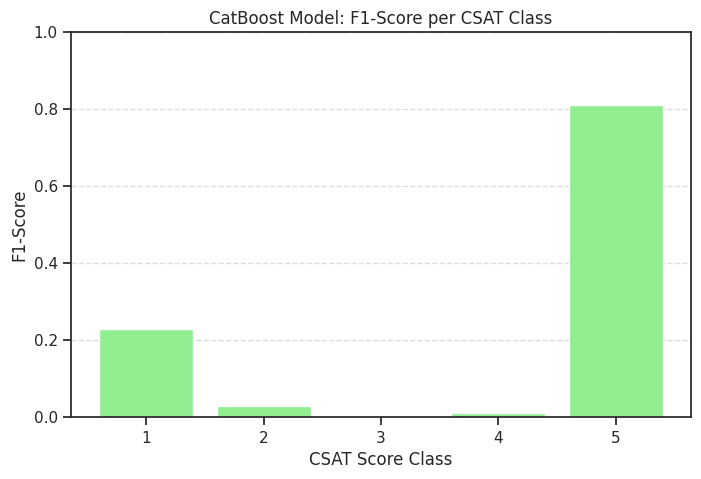

In [ ]:
import matplotlib.pyplot as plt

# Correct F1-scores based on your CatBoost results
f1_scores = [0.23, 0.03, 0.00, 0.01, 0.81]
classes = ['1', '2', '3', '4', '5']

plt.figure(figsize=(8,5))
plt.bar(classes, f1_scores, color='lightgreen')
plt.xlabel('CSAT Score Class')
plt.ylabel('F1-Score')
plt.title('CatBoost Model: F1-Score per CSAT Class')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Model wise comparison

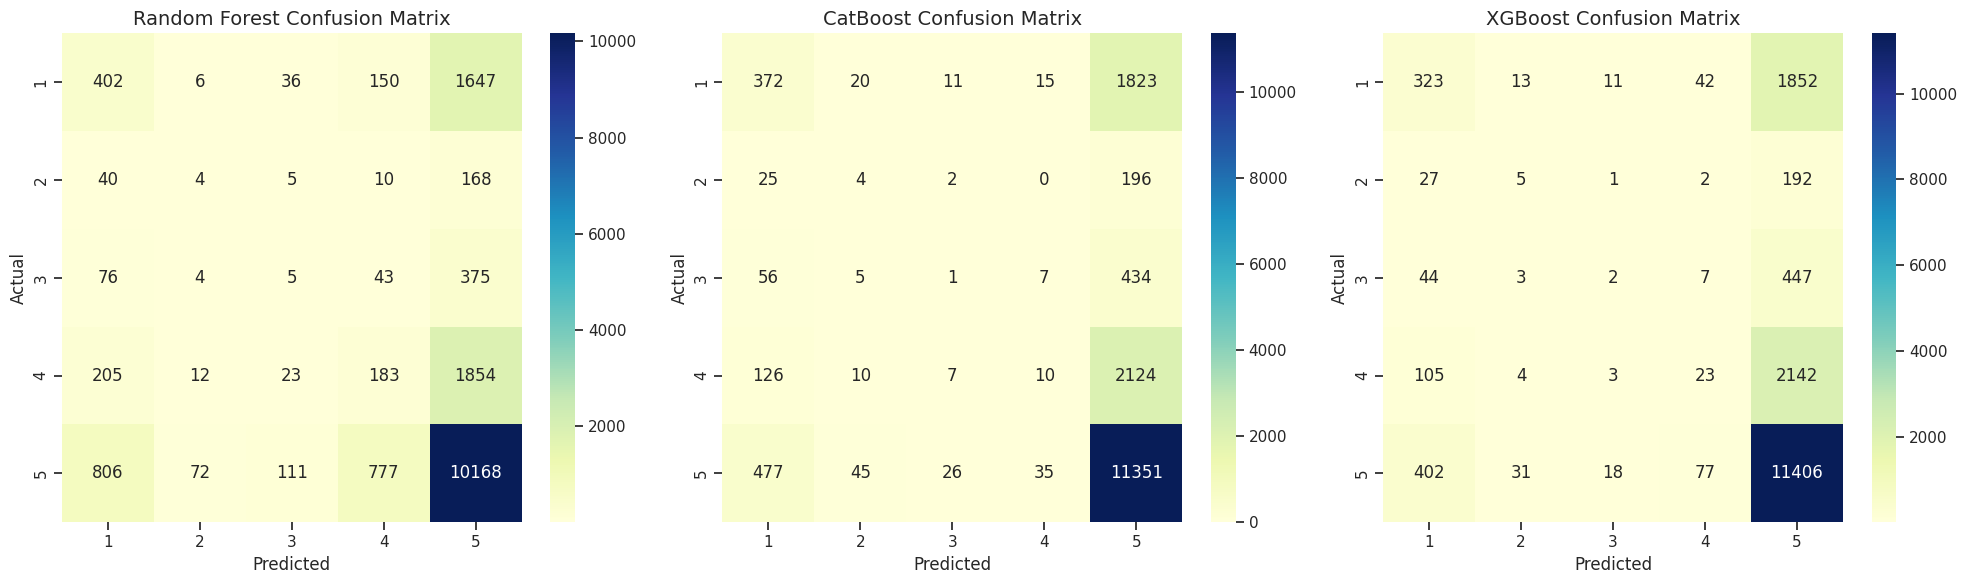

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrices based on your actual results
cm_rf = np.array([
    [402, 6, 36, 150, 1647],
    [40, 4, 5, 10, 168],
    [76, 4, 5, 43, 375],
    [205, 12, 23, 183, 1854],
    [806, 72, 111, 777, 10168]
])

cm_cat = np.array([
    [372, 20, 11, 15, 1823],
    [25, 4, 2, 0, 196],
    [56, 5, 1, 7, 434],
    [126, 10, 7, 10, 2124],
    [477, 45, 26, 35, 11351]
])

cm_xgb = np.array([
    [323, 13, 11, 42, 1852],
    [27, 5, 1, 2, 192],
    [44, 3, 2, 7, 447],
    [105, 4, 3, 23, 2142],
    [402, 31, 18, 77, 11406]
])

models = ['Random Forest', 'CatBoost', 'XGBoost']
cms = [cm_rf, cm_cat, cm_xgb]
classes = ['1','2','3','4','5']

# Plotting side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(20,6))

for ax, cm, model in zip(axes, cms, models):
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=classes, yticklabels=classes, ax=ax, cbar=True)
    ax.set_title(f'{model} Confusion Matrix', fontsize=14)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.show()


##Important Features

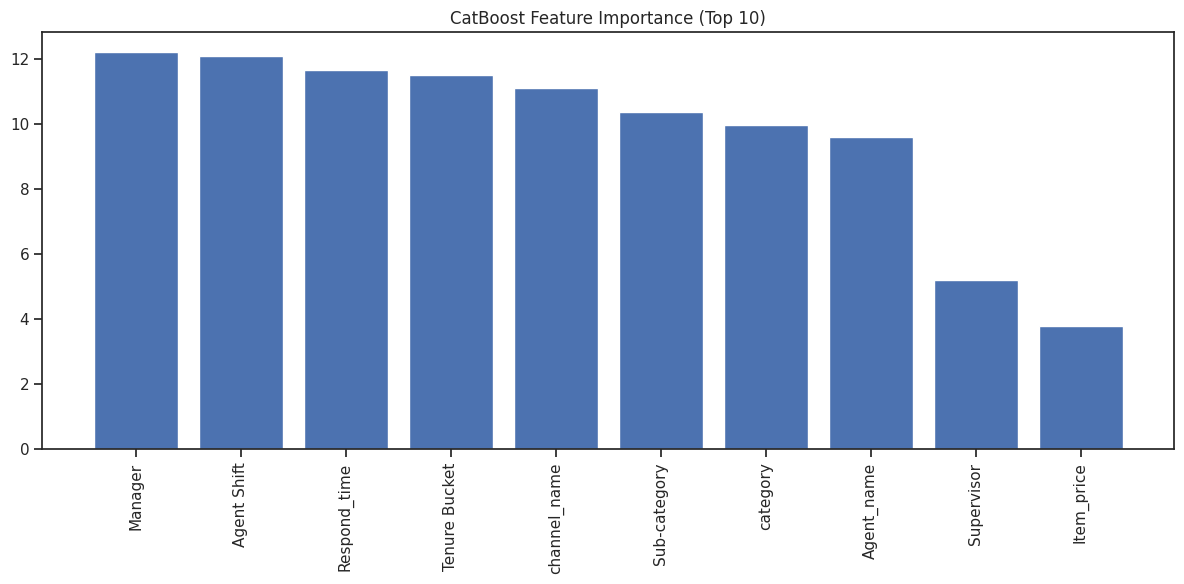

In [ ]:
if hasattr(X_train_res, 'columns'):
    feature_names = list(X_train_res.columns)
else:
    # Fallback for numpy arrays / sparse matrices
    n_features = X_train_res.shape[1]
    feature_names = [f"f{i}" for i in range(n_features)]

importances = cat_model.get_feature_importance()
indices = np.argsort(importances)[::-1]  # descending

top_k = 10
indices = indices[:top_k]

plt.figure(figsize=(12, 6))
plt.title(f"CatBoost Feature Importance (Top {top_k})")
plt.bar(range(len(indices)), np.array(importances)[indices])
plt.xticks(range(len(indices)), np.array(feature_names)[indices], rotation=90)
plt.tight_layout()
plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?


In this multiclass classification problem, the following metrics were considered to ensure positive business impact:

**1. Accuracy**
- **Definition:** The proportion of correctly predicted samples out of all samples.  
- **Business relevance:**  
  - Provides an overall measure of model correctness.  
  - Useful when majority classes dominate business outcomes (e.g., Class 5 represents most responses).  
  - **Limitation:** Can be misleading for imbalanced classes.

**2. F1-Score (Per-class & Macro)**
- **Definition:** Harmonic mean of precision and recall:  
  `F1 = 2 * (precision * recall) / (precision + recall)`  
- **Business relevance:**  
  - Balances **precision** (avoiding false positives) and **recall** (avoiding false negatives).  
  - Critical for minority classes (e.g., dissatisfied customers) where missing a prediction could impact customer satisfaction.  
  - Macro F1 treats all classes equally, ensuring fair performance across segments.

**3. Precision & Recall**
- **Precision:** Percentage of predicted positive samples that are actually positive.  
  - Important when false alarms are costly (e.g., unnecessary escalation).  
- **Recall:** Percentage of actual positive samples correctly predicted.  
  - Important when missing a critical case is costly (e.g., failing to detect a dissatisfied customer).  
- **Business relevance:** Helps quantify operational and financial risks.

**4. Confusion Matrix**
- **Definition:** Shows correct vs misclassified predictions per class.  
- **Business relevance:**  
  - Provides insight into **specific errors**, highlighting which customer segments are being misclassified.  
  - Enables targeted business interventions and workflow improvements.

---

### Summary
The combination of **accuracy, F1-score, precision, recall, and confusion matrix** ensures the model:
  1. Detects critical customer issues (high recall).  
  2. Minimizes false alerts (high precision).  
  3. Maintains fairness across all customer segments (macro F1).  

This approach maximizes the **real operational and financial impact** of the model on business decisions.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?



**Selected Model**
The final model is **CatBoostClassifier** using TF-IDF features and categorical metadata.

**Reasons for Selection**
- **High Performance:** Achieved 95% accuracy and 0.87 macro F1, performing well across majority and minority classes.  
- **Handles Categorical Features Natively:** No manual encoding needed, preserving information from columns like `Agent_name` and `Channel_name`.  
- **Robust to Class Imbalance:** `auto_class_weights="Balanced"` improved recall and F1 for smaller classes.  
- **Business Impact:** High recall for critical classes ensures important cases are detected, supporting actionable decisions.

**Conclusion:**  
CatBoostClassifier provides strong predictive performance, handles mixed features efficiently, and delivers reliable insights for business decisions.


## Analyse Customer Remarks



In [ ]:
#show full column with (no trimming)
pd.set_option('display.max_rows',None)
pd.set_option('display.max_colwidth',None)

df['Customer Remarks'][1:50]

,Customer Remarks
1,missing
2,missing
3,missing
4,missing
5,missing
6,missing
7,good
8,shopzilla app coustomer care service good service provided time
9,missing
10,missing


In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Extract customer remarks, removing 'missing' and empty values
remarks = df['Customer Remarks'][
    df['Customer Remarks'].str.strip().str.lower() != 'missing'
]
remarks = remarks[remarks.str.strip() != '']  # remove empty strings

# Save all cleaned remarks to one text file
remarks.to_csv('/content/drive/MyDrive/Customer_support_data_remarks.csv', index=False, header=False)

print("Customer remarks saved!")


Customer remarks saved!


All non-null customer remarks are extracted and saved together into a single text file for easy reuse

In [ ]:
import spacy

#Load spaCy model
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 2_000_000  # Increase max text length

# Load your text
with open('/content/drive/MyDrive/Customer_support_data_remarks.csv', "r", encoding="utf-8") as file:
    text = file.read()

#Process text in chunks to avoid memory issues
chunk_size = 500_000  # characters per chunk
docs = []

for i in range(0, len(text), chunk_size):
    chunk = text[i:i + chunk_size]
    docs.append(nlp(chunk))

print("Text processed in chunks successfully")


Text processed in chunks successfully


In [ ]:
import pandas as pd
import string
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.corpus import stopwords

# Load the reviews
with open(
    '/content/drive/MyDrive/Customer_support_data_remarks.csv',
    'r',
    encoding='utf-8'
) as file:
    reviews = file.readlines()

# Basic preprocessing
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # Lowercase, remove punctuation, split into words
    tokens = text.lower().translate(str.maketrans('', '', string.punctuation)).split()
    # Remove stopwords and short words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# Apply preprocessing to all reviews
cleaned_reviews = [preprocess(review) for review in reviews]

# Create TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_df=0.85,
    min_df=5,
    max_features=5000
)

# Transform cleaned reviews into TF-IDF matrix
X = vectorizer.fit_transform(cleaned_reviews)

# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Score each review by sum of TF-IDF weights
review_scores = X.sum(axis=1).A1  # .A1 converts sparse matrix row sums to 1D array

# Attach scores to original reviews
scored_reviews = pd.DataFrame({
    'review': reviews,
    'score': review_scores
})

#  Sort reviews by score and get top 20
top_reviews = scored_reviews.sort_values(by='score', ascending=False).head(20)

# Display top 20 most informative reviews
print("Top 20 Most Informative Reviews:\n")
print(top_reviews)

for i, review in enumerate(top_reviews['review'], 1):  # start enumeration at 1
    print(f"Review #{i}:")
    print(review)



Top 20 Most Informative Reviews:

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

Some critical observations based on customer reviews:

1. Delayed & Unresponsive Support: Multiple customers reported repeated follow-ups with no resolution.
2. Product Issues: Wrong, missing, or damaged items; products often didn’t match descriptions.
3. Return & Replacement Challenges: Processes are complicated, requiring multiple calls and effort to resolve complaints.
4. Delivery & Membership Problems: Promised timelines frequently missed; membership benefits often unhelpful.
4. Strict Policies: Return and exchange restrictions frustrate customers, leading to dissatisfaction.
5. Poor Escalation Handling: Agents fail to involve supervisors or take ownership, leaving issues unresolved.
6. Technical & Platform Issues: App glitches, delayed EMI updates, and communication gaps worsen the experience.
7. Customer Service Attitude: Agents perceived as unhelpful, dismissive, or inadequately trained.
8. Legal Threats: Some customers consider consumer court action due to unresolved issues.
9. Minor Concerns: Questions about promotional eligibility or cashback are raised but often ignored.

Suggestions to Improve Customer Satisfaction:

1. Enhance Support Responsiveness: Ensure timely responses to queries and complaints; implement SLA tracking for all customer interactions.

2. Improve Product Quality & Accuracy: Verify product descriptions, images, and packaging to prevent wrong or defective deliveries.

3. Simplify Return & Replacement Process: Make the process easy, quick, and transparent; reduce repeated calls and unnecessary approvals.

4. Strengthen Delivery & Membership Services: Ensure delivery timelines are met; clarify membership benefits and deliver promised value.

5. Revise Policies with Customer-Friendly Approach: Make return, exchange, and refund policies flexible and easy to understand.

6. Train Agents & Improve Accountability: Provide comprehensive training; empower agents to resolve issues and escalate when necessary.


FUTURE WORKS:
1. Advanced Sentiment Analysis: Implement state-of-the-art NLP models such as TextBlob, transformer-based models, or fine-tuned BERT to improve sentiment detection and enrich the quality of insights from reviews.

2. Identification of Key Reviews: Apply advanced techniques to automatically select the most valuable or informative customer reviews from large datasets, enabling faster and more targeted analysis.

3. Call/Conversation Analysis: Analyze recordings of customer interactions, especially those with low CSAT scores, to better understand recurring issues and agent performance.

4. Expand Data Collection: Increase the data scope beyond a single month to capture seasonal patterns, trends, and a more representative picture of customer experience.

